# 1 项目介绍：
Word2Vec是由谷歌团队于2013年发布的词嵌入工具，其主要的思想是单词的含义由其上下文定义。主要包含了两种模型：Skip-gram和CBOW模型。  
1）Skip-gram：根据目标词去预测周围词来训练得到词向量；  
2）CBOW：根据上下文取预测目标词来训练得到词向量  
本项目旨在利用 PyTorch 训练一个连续词袋模型（CBOW），以 ModelScope 平台中的金庸小说数据集为基础，生成词向量。在此基础上，将文本中的人名和机构名进行可视化，以展示词与词之间的关系。

# 2 CBOW模型架构
1）对输入单词进行独热编码  
2）嵌入层（Embedding层），将所有单词变成100维向量  
3）对单词嵌入向量进行平均，以获得单一的固定长度向量，代表整个上下文信息  
4）使用Softmax的线性层，用来输出概率  
以上是最为经典、原始的CBOW。在下面构建的CBOW中，添加非线性激活函数ReLU，以提升模型的表达能力
参考链接：https://zerolovesea.github.io/2024/02/11/%E4%BB%A3%E7%A0%81%E5%AE%9E%E6%88%98%EF%BC%9AWord2Vec%E7%9A%84Pytorch%E5%AE%9E%E7%8E%B0/#%E8%AE%AD%E7%BB%83%E4%BB%A3%E7%A0%81

In [1]:
import torch
from torch import nn
from torch.nn import functional as F

# 定义CBOW 神经网络
# 继承nn.Module类，构建自己的神经网络
class Word2VecModel_CBOW(nn.Module):
    def __init__(self, vocab_size, word_embedding_size=100, hidden=64):
        """
        Word2vec模型CBOW实现
        :param vocab_size: 单词个数
        :param word_embedding_size: 每个词的词向量维度
        :param hidden: 隐藏层（全连接层）的维度（默认64，在保证模型性能的同时，避免过大的计算开销）
        """
        super(Word2VecModel_CBOW, self).__init__()
        self.vocab_size = vocab_size
        self.word_embedding_size = word_embedding_size
        self.hidden = hidden
        # nn.Embedding 是 PyTorch 的嵌入层，将单词的索引（如 0, 1, 2...）映射为稠密向量（维度为 word_embedding_size）
        self.word_embedding = nn.Embedding(self.vocab_size, self.word_embedding_size)  # token对应的embedding
        # 建模
        # 将上下文单词的平均词向量（维度 word_embedding_size）映射到隐层（维度 hidden）
        self.linear_in = nn.Linear(self.word_embedding_size, self.hidden)
        # 将隐层输出（维度 hidden）映射到词汇表维度（vocab_size），最终输出每个单词的概率分布。
        self.linear_out = nn.Linear(self.hidden, self.vocab_size)
    # input_labels 是形状为 [batch_size, context_size] 的张量，表示每个样本的上下文单词索引
    def forward(self, input_labels):
        # 将上下文单词的索引转换为词向量，形状为 [batch_size, context_size, word_embedding_size]。
        around_embedding = self.word_embedding(input_labels)
        
        #对上下文单词的词向量在第1维（context_size 维）进行平均，得到每个样本的上下文向量，形状为 [batch_size, word_embedding_size]
        avg_around_embedding = torch.mean(around_embedding, dim=1) 
    
        # 通过linear_in全连接层将向量映射到隐层维度hidden，并使用 ReLU 激活函数引入非线性。
        in_emb = F.relu(self.linear_in(avg_around_embedding)) 
        
        # 通过 linear_out 全连接层将隐层输出映射到词汇表维度 vocab_size，并使用 log_softmax 计算每个单词的对数概率分布。
        # 输出形状为 [batch_size, vocab_size]，表示每个样本对目标词的预测概率。
        out_emb = F.log_softmax(self.linear_out(in_emb),dim=-1)  
        return out_emb

# 3 数据处理
1）文本清洗，句子分割，句子分词  
2）构建词汇表vocab{词：索引}  
3）生成训练样本([word(t-2),word(t-1),word(t+1),word(t+2)],word(t))  
4）将训练样本中单词变成索引  
5）划分batchs与填充样本  
数据来源与参考：https://github.com/NSun-S/buaa_nlp_project4

In [2]:
import jieba
import re

def clean_text(text):
    """清洗文本：去除所有空白字符（空格、换行符等）"""
    text = re.sub(r'\s+', '', text)  # 删除所有空白字符
    return text.strip()  # 去除首尾可能残留的空白

def split_sentences(text):
    """按标点分割句子"""
    sentences = []
    # 按标点符号分割句子
    splits = re.split(r'([。！？\.\?!…])', text)
    for i in range(0, len(splits), 2):
        if i+1 < len(splits):
            sentence = splits[i] + splits[i+1]
            sentence = sentence.strip()
            if sentence:
                sentences.append(sentence)
    return sentences

def tokenize_sentence(sentence, stopwords):
    """分词并去除停用词"""
    words = jieba.lcut(sentence)
    words = [word for word in words if word and word not in stopwords]
    return words

file_paths=['data/射雕英雄传.txt','data/神雕侠侣.txt','data/天龙八部.txt','data/笑傲江湖.txt','data/倚天屠龙记.txt']
output_path = "preprocessed.txt"
stopwords_path = "stopwords.txt"  # 自定义停用词表路径
#读取停用词
with open(stopwords_path,'r',encoding='utf-8') as f:
    stopwords=f.readlines()
    # 去除空格和换行符
    stopwords=[stopword.strip() for stopword in stopwords]
# 添加自定义词典
jieba.load_userdict("人物.txt")
jieba.load_userdict("武功.txt")
jieba.load_userdict("帮派.txt")
# 将所有处理后的文本保存在一个文件中
with open(output_path, 'w', encoding='utf-8') as out_f:
    for file_path in file_paths:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
            text=clean_text(text)
            # 分割句子
            sentences = split_sentences(text)
            print("《{}》的句子数量：{}".format(file_path.split(".")[0].split("/")[-1],len(sentences)))
            print("句子示例{}".format(sentences[10:15]))
            # 分词并处理每句话
            for sent in sentences:
                words = tokenize_sentence(sent, stopwords)
                if words:
                    out_f.write(' '.join(words) + '\n')

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Mingyu\AppData\Local\Temp\jieba.cache
Loading model cost 0.497 seconds.
Prefix dict has been built successfully.


《射雕英雄传》的句子数量：30226
句子示例['他四人给金兵冲散，好容易又再团聚，欢天喜地的回到故乡，却见房屋已给金兵烧得干干净净，无可奈何，只得去到汴梁，想觅个生计。', '不料想：天有不测风云，人有旦夕祸福。', '他四人刚进汴梁城，迎面便过来一队金兵。', '带兵的头儿一双三角眼觑将过去，只见那叶三姐生得美貌，跳下马来，当即一把抱住，哈哈大笑，便将她放上了马鞍，说道：‘小姑娘，跟我回家，服侍老爷。', '’那叶三姐如何肯从？']
《神雕侠侣》的句子数量：30733
句子示例['节近中秋，荷叶渐残，莲肉饱实。', '这一阵歌声传入湖边一个道姑耳中。', '她在一排柳树下悄立已久，晚风拂动她杏黄色道袍的下摆，拂动她颈中所插拂尘的万缕柔丝，心头思潮起伏，当真亦是「芳心只共丝争乱」。', '只听得歌声渐渐远去，唱的是欧阳修另一首「蝶恋花」词，一阵风吹来，隐隐送来两句：「风月无情人暗换，旧游如梦空肠断…', '…']
《天龙八部》的句子数量：43015
句子示例['眼见那少年与中年汉子已拆到七十余招，剑招越来越紧，兀自未分胜败。', '突然中年汉子一剑挥出，用力猛了，身子微微一幌，似欲摔跌。', '西边宾客中一个身穿青衫的年轻男子忍不住“嗤”的一声笑。', '他随即知道失态，忙伸手按住了口。', '便在这时，场中少年左手呼一掌拍出，击向那汉子后心，那汉子向前跨出一步避开，手中长剑蓦地圈转，喝一声：“着！']
《笑傲江湖》的句子数量：35346
句子示例['当先一匹马全身雪白，马勒脚镫都是烂银打就，鞍上一个锦衣少年，约莫十八九岁年纪，左肩上停着一头猎鹰，腰悬宝剑，背负长弓，泼喇喇纵马疾驰。', '身后跟随四骑，骑者一色青布短衣。', '一行五人驰到镖局门口，八名汉子中有三个齐声叫了起来：“少镖头又打猎去啦！', '”那少年哈哈一笑，马鞭在空中拍的一响，虚击声下，胯下白马昂首长嘶，在青石板大路上冲了出去。', '一名汉子叫道：“史镖头，今儿再抬头野猪回来，大伙儿好饱餐一顿。']
《倚天屠龙记》的句子数量：31769
句子示例['《词品》评论此词道：“长春，世之所谓仙人也，而词之清拔如此”。', '这首词诵的似是梨花，其实词中真意却是赞誉一位身穿白衣的美貌少女，说她“浑似姑射真人，天姿灵秀，意气殊高洁”，又说她“浩气清英，仙才卓荦”，“不与群芳同列”。', '词中所颂这美女

In [3]:
all_sentences=[]
with open("preprocessed.txt", 'r', encoding='utf-8') as f:
    lines = f.readlines()
    print(lines[1:10])
    for line in lines:
        words = line.strip().split()  # 按空格分割词语
        all_sentences.append(words)
print("总句子数：",len(all_sentences))
print(all_sentences[1:10])

['江畔 一排 数十株 乌 柏树 叶子 似 火烧 般红 正是 八月 天时\n', '村前村后 野草 刚 起始 变黄 一抹 斜阳 映照 之下 更增 几分 萧索\n', '两株 大 松树 下 围着 一堆 村民 男男女女 十几个 小孩 正自 聚精会神 听 一个 瘦削 老者 说话\n', '说话 人 五十 岁 年纪 一件 青布 长袍 早洗 褪成 蓝灰色\n', '只 听 两片 梨花 木板 碰 几下 右手 中 竹棒 小 羯鼓 上 敲起 连声\n', '唱道 小桃 无主自 开花 烟草 茫茫 带 晚鸦\n', '几处 败垣围 故井 向来 一一\n', '说话 人 木板 敲 几下 说道 这首 七言诗 说 兵火 过后 家家户户 都 断 墙 残瓦 破败 之地\n', '小人 刚才 说 叶老汉 一家 四口 悲欢离合 聚 散 散 聚\n']
总句子数： 161849
[['江畔', '一排', '数十株', '乌', '柏树', '叶子', '似', '火烧', '般红', '正是', '八月', '天时'], ['村前村后', '野草', '刚', '起始', '变黄', '一抹', '斜阳', '映照', '之下', '更增', '几分', '萧索'], ['两株', '大', '松树', '下', '围着', '一堆', '村民', '男男女女', '十几个', '小孩', '正自', '聚精会神', '听', '一个', '瘦削', '老者', '说话'], ['说话', '人', '五十', '岁', '年纪', '一件', '青布', '长袍', '早洗', '褪成', '蓝灰色'], ['只', '听', '两片', '梨花', '木板', '碰', '几下', '右手', '中', '竹棒', '小', '羯鼓', '上', '敲起', '连声'], ['唱道', '小桃', '无主自', '开花', '烟草', '茫茫', '带', '晚鸦'], ['几处', '败垣围', '故井', '向来', '一一'], ['说话', '人', '木板', '敲', '几下', '说道', '这首', '七言诗', '说', '兵火', '过后', '家家户户', '都', '断', '墙', '残瓦', '破败', '之地'], ['小人', '刚才', '说', '叶老汉', 

In [4]:
# 构建词汇表
from collections import defaultdict

def build_vocab(sentences, min_freq=5):
    # 统计词频并构建词到索引的映射
    word_freq = defaultdict(int) # 创建一个defaultdict，默认值为int()，即0。当访问不存在的键时，会返回该类型对象或函数对象的默认值
    for sentence in sentences:
        for word in sentence:
            word_freq[word]=word_freq[word]+1
    # 过滤低频词并添加特殊符号
    vocab = {"<UNK>": 0}  # 未知词标记
    idx = 1
    # 为词添加索引
    for word, count in word_freq.items():
        if count >= min_freq:
            vocab[word] = idx
            idx=idx+1
    return vocab

vocab = build_vocab(all_sentences)
vocab_size = len(vocab)
print("词汇表大小: ",vocab_size)

词汇表大小:  31713


In [5]:
# 生成CBOW训练样本
# CBOW模型输入是上下文词列表，输出是目标词。例如，窗口大小为2时，每个目标词的上下文是前2个和后2个词：
import random

def generate_cbow_samples(sentences, window_size=2):
    # 生成CBOW训练样本：(上下文词列表, 目标词)
    samples = []
    for sentence in sentences:
        for i in range(len(sentence)):
            center = sentence[i]
            context = []
            # 收集窗口内的上下文词（排除中心词本身）
            for j in range(i - window_size, i + window_size + 1):
                if j != i and 0 <= j < len(sentence):
                    context.append(sentence[j])
            if context:
                samples.append((context, center))
    random.shuffle(samples)  # 打乱样本顺序
    return samples

window_size=2  # 窗口大小（每个方向取2个词）
samples = generate_cbow_samples(all_sentences, window_size)
print("总样本数:",len(samples))
print("样本示例：",samples[1:10])

总样本数: 1764441
样本示例： [(['跪', '看不清楚', '膝盖'], '地下'), (['二人', '动手', '定', '吃亏'], '马光佐'), (['俏鬼', '掷', '道', '九妹'], '去'), (['不得了', '快', '去', '请'], '快'), (['略侧', '已', '心来', '剑'], '后'), (['无知', '却决'], '弟子'), (['大', '喝道', '壁上', '图形'], '别看'), (['两字', '出口'], '拿来'), (['人群', '中', '说道', '客气话'], '有人')]


In [6]:
# 将单词转换为索引
def convert_to_indices(samples, vocab):
    """将单词转换为词汇表中的索引"""
    X = []  # 上下文词的索引列表
    y = []  # 目标词的索引
    for context, center in samples:
        # 将上下文词转换为索引（未知词用<UNK>）
        context_indices = [vocab.get(word, vocab["<UNK>"]) for word in context]
        center_idx = vocab.get(center, vocab["<UNK>"])
        X.append(context_indices)
        y.append(center_idx)
    return X, y

X, y = convert_to_indices(samples, vocab)
print(X[0:5])
print(y[0:5])

[[16459, 100], [431, 8600, 12868], [307, 1503, 1164, 1499], [27511, 1935, 285, 0], [3482, 1417, 107, 287]]
[12776, 432, 25918, 107, 1417]


In [7]:
# 批次与填充
# 由于CBOW的上下文长度可能不固定（取决于窗口大小和句子长度），需要填充（padding）以统一输入长度：
import numpy as np

def create_batches(X, y, batch_size=32, pad_value=0):
    """创建批次并填充上下文列表到相同长度"""
    # 计算最大上下文长度（固定窗口大小时可省略）
    max_len = max(len(context) for context in X)
    # 填充并转换为numpy数组
    X_padded = []
    for context in X:
        padded = context + [pad_value] * (max_len - len(context))
        X_padded.append(padded)
    X_padded = np.array(X_padded)
    y = np.array(y)
    # 分批次
    batches = []
    for i in range(0, len(X), batch_size):
        batch_X = X_padded[i:i+batch_size]
        batch_y = y[i:i+batch_size]
        batches.append((batch_X, batch_y))
    return batches

batch_size = 128
batches = create_batches(X, y, batch_size)
print("总批次数:",len(batches))
print(batches[0:1])

总批次数: 13785
[(array([[16459,   100,     0,     0],
       [  431,  8600, 12868,     0],
       [  307,  1503,  1164,  1499],
       [27511,  1935,   285,     0],
       [ 3482,  1417,   107,   287],
       [ 5364,   102,   780,  1393],
       [13791, 25858,     0,     0],
       [   35,   141, 12304, 11888],
       [ 2178,  7445,     0,     0],
       [10982,    65,    77, 27421],
       [14641,  5233,  4584,     0],
       [   77,  3605, 11582, 28162],
       [   79,  3041,   111,   421],
       [ 6753,  8095,  8739,     0],
       [ 1044,  6869,   814,  1097],
       [    0,  1393,  5663,   658],
       [ 4067,     0,     0,     0],
       [ 2149,  2446,   358,    94],
       [20720,  3386,     0,     0],
       [ 3137,   144,  2877,     0],
       [ 5279, 22916,   275,    68],
       [  858,     0,     0,     0],
       [   47, 30604,  3606,  1393],
       [21478, 24310, 10374,  6829],
       [  728,   891,     0,     0],
       [   79,  1165,  2328, 24925],
       [ 7399,     0,  2

# 4 模型训练

In [24]:
model = Word2VecModel_CBOW(vocab_size,word_embedding_size=100,hidden=64)
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#设置训练轮数
epochs=3
for i in range(epochs):
    epoch_loss=0.0
    # 训练循环
    for batch_X, batch_y in batches:
        inputs = torch.tensor(batch_X, dtype=torch.long)
        targets = torch.tensor(batch_y, dtype=torch.long)
        # 清除梯度
        optimizer.zero_grad()
        # 前向传播
        outputs = model(inputs)
        #计算损失
        loss = criterion(outputs, targets)
        #反向传播和参数更新
        loss.backward()
        optimizer.step()
        
        # 累加损失
        epoch_loss += loss.item()
    
    # 打印当前 epoch 的平均损失
    avg_loss = epoch_loss / len(batches)  # 平均损失
    print(f"Epoch [{i+1}/{epochs}], Loss: {avg_loss:.4f}")
    
    # 保存当前 epoch 的模型参数
    model_path = f"saved_models/model_epoch_{i+1}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Epoch [1/3], Loss: 8.1712
Model saved to saved_models/model_epoch_1.pth
Epoch [2/3], Loss: 7.6386
Model saved to saved_models/model_epoch_2.pth
Epoch [3/3], Loss: 7.2918
Model saved to saved_models/model_epoch_3.pth


# 5 权重调用

In [12]:
from torch.nn.functional import cosine_similarity

# 加载最佳模型
best_model_path = f"saved_models/model_epoch_3.pth"
model.load_state_dict(torch.load(best_model_path))
model.eval()  # 切换到评估模式

# 获取嵌入权重
embedding_weights = model.word_embedding.weight.data.numpy() #word_embedding是模型中自己命名的Embedding层

# 测试词汇表是否包含目标词yizhitan
test_words = ["黄蓉", "郭靖", "华山派", "桃花岛"]
for word in test_words:
    if word not in vocab:
        raise KeyError(f"'{word}' 不在词汇表中，请检查词汇表内容！")

# 获取词索引
黄蓉_index = vocab["黄蓉"]
郭靖_index = vocab["郭靖"]
华山派_index = vocab["华山派"]
桃花岛_index = vocab["桃花岛"]

# 获取词的嵌入向量（NumPy -> PyTorch 张量）
黄蓉_embedding = torch.tensor(embedding_weights[黄蓉_index]).unsqueeze(0)
郭靖_embedding = torch.tensor(embedding_weights[郭靖_index]).unsqueeze(0)
华山派_embedding = torch.tensor(embedding_weights[华山派_index]).unsqueeze(0)
桃花岛_embedding = torch.tensor(embedding_weights[桃花岛_index]).unsqueeze(0)

# 计算余弦相似度
similarity_1 = cosine_similarity(黄蓉_embedding, 郭靖_embedding)
similarity_2 = cosine_similarity(黄蓉_embedding, 华山派_embedding)
similarity_3 = cosine_similarity(桃花岛_embedding, 华山派_embedding)

# 打印结果
print(f"余弦相似度 between '黄蓉' and '郭靖': {similarity_1.item():.4f}")
print(f"余弦相似度 between '黄蓉' and '华山派': {similarity_2.item():.4f}")
print(f"余弦相似度 between '桃花岛' and '华山派': {similarity_3.item():.4f}")

余弦相似度 between '黄蓉' and '郭靖': 0.1169
余弦相似度 between '黄蓉' and '华山派': 0.0687
余弦相似度 between '桃花岛' and '华山派': 0.1397


# 6 词向量可视化

In [13]:
#词汇表vocab，前面已经定义过
# 人名列表
with open("人物.txt","r",encoding="utf-8") as f:
    persons=[name.strip() for name in f.readlines()]  

    
# 获取人名的词向量
def get_words_vector(words,vocab,word_vectors):
    words_vectors=[]
    word_exist=[]
    for word in words:
        if word in vocab:
            index = vocab[word]
            words_vectors.append(word_vectors[index])
            word_exist.append(word)
    return words_vectors,word_exist

person_vectors,person_exist = get_words_vector(persons, vocab, embedding_weights)

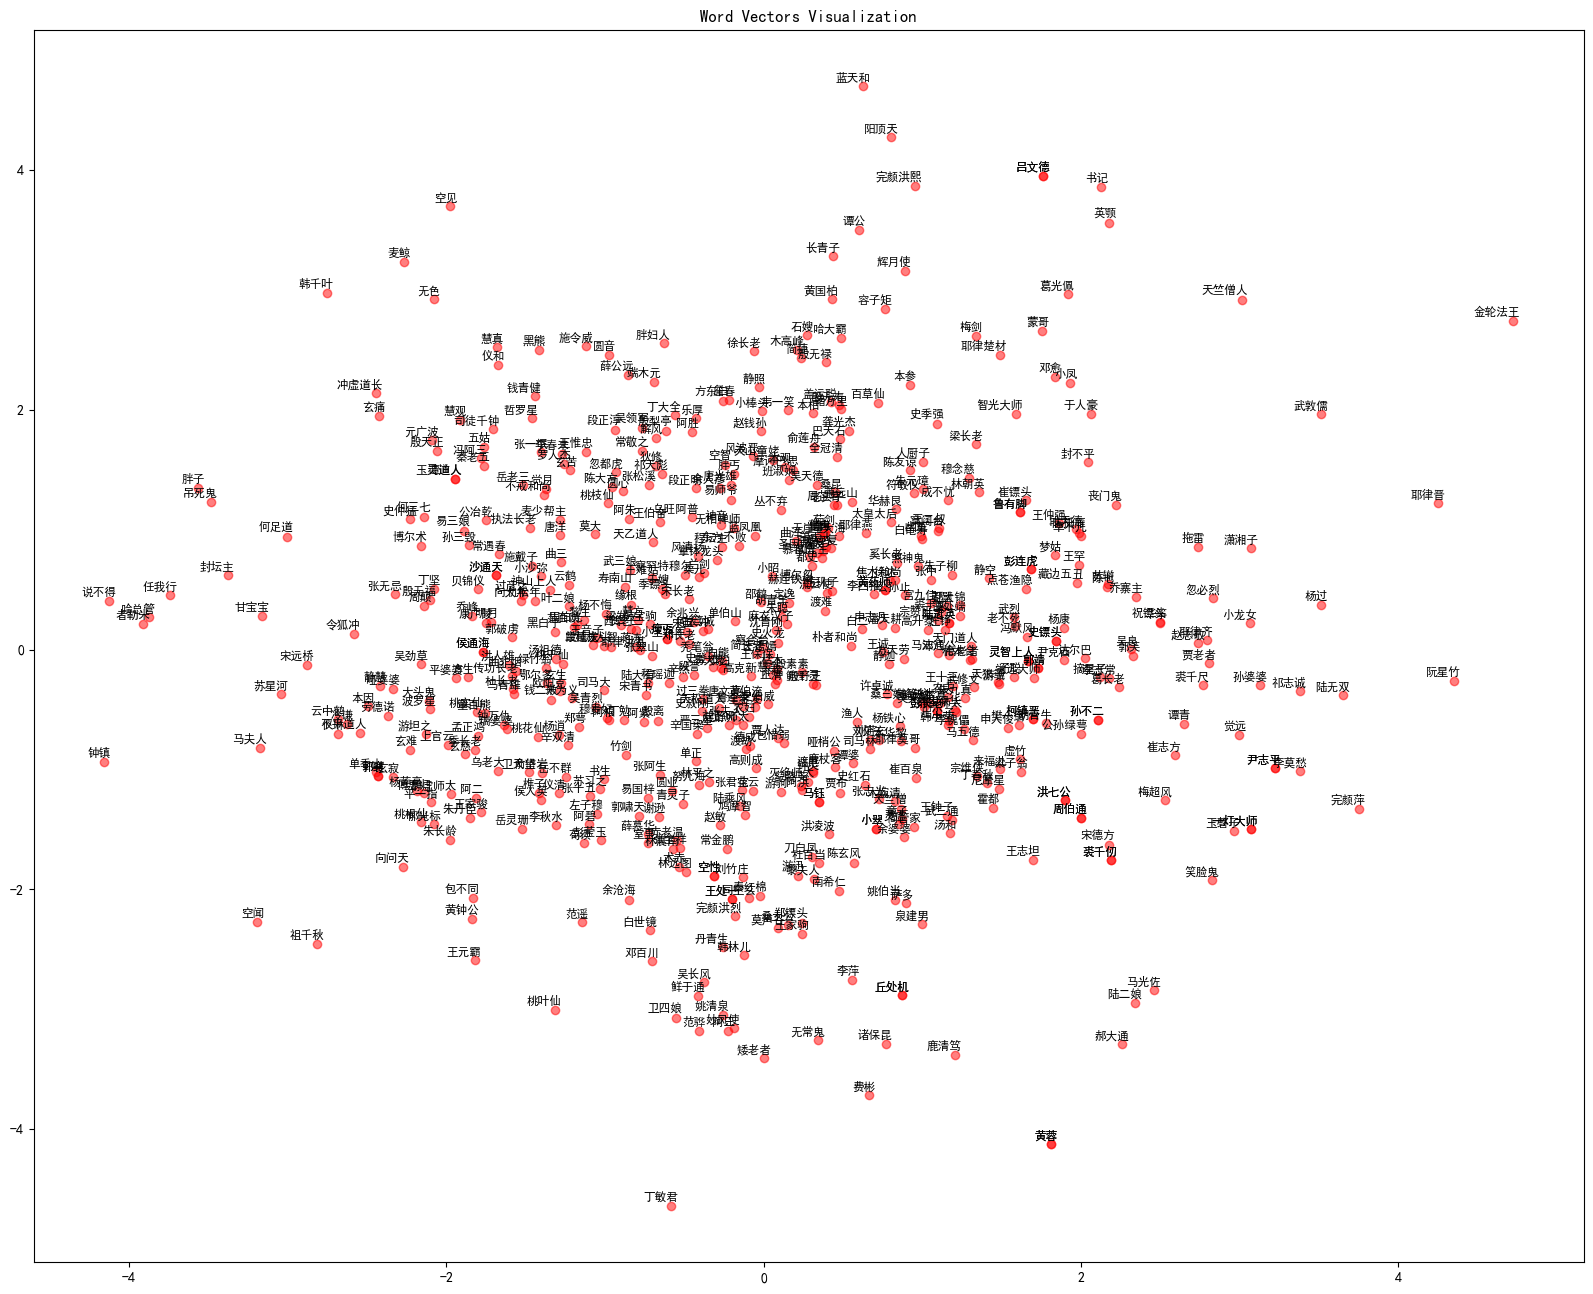

In [16]:
# 使用PAC进行降维
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

all_vectors = person_vectors
labels = person_exist

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(all_vectors)

# 绘制散点图
plt.figure(figsize=(20, 16))
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 为每个点添加标签
for i,(x, y) in enumerate(vectors_2d):
    plt.scatter(x, y, color="red",alpha=0.5)
    plt.annotate(labels[i], 
                 xy=(x, y), 
                 xytext=(5, 2),
                 textcoords='offset points',
                 fontsize='small',
                 ha='right',
                 va='bottom')
                 #rotation=90)

# 添加标题和图例
plt.title("Word Vectors Visualization")

# 显示图形
plt.show()

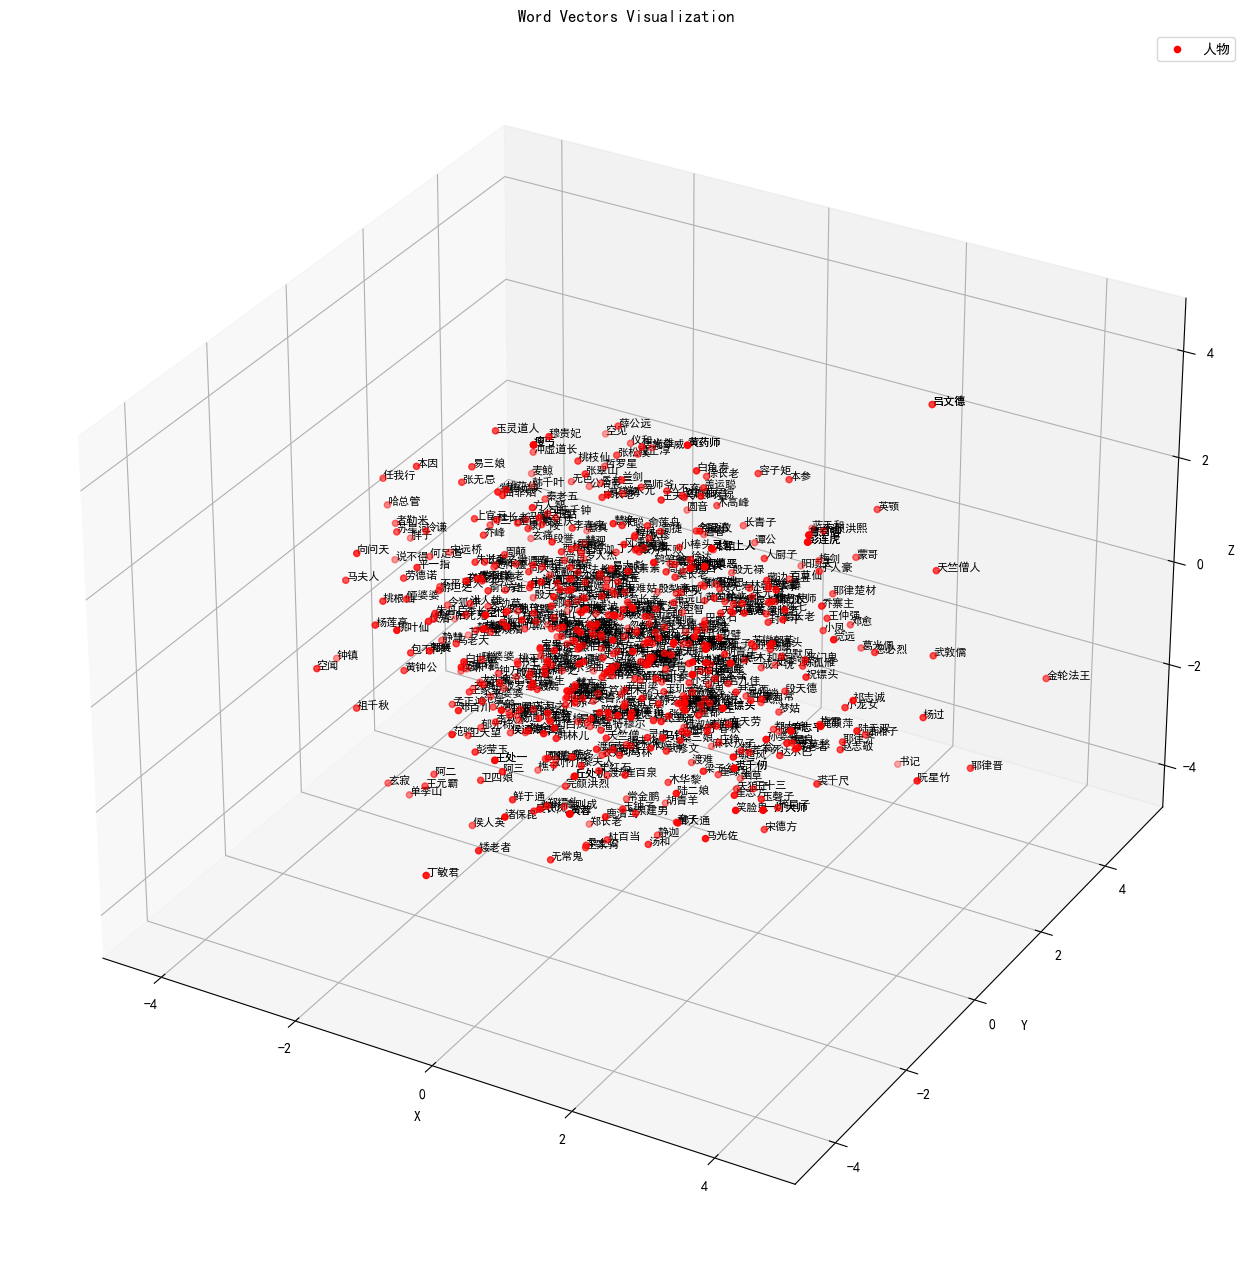

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 必须引入这个模块才能使用3D绘图
import numpy as np

# 假设已经定义好了 person_vectors, org_vectors, person_exist, org_exist

all_vectors = person_vectors
labels = person_exist

# 使用 PCA 降维到 3D
pca = PCA(n_components=3)
vectors_3d = pca.fit_transform(all_vectors)

# 创建图形对象
fig = plt.figure(figsize=(20, 16))
ax = fig.add_subplot(111, projection='3d')  # 添加一个3D子图

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 绘制人物散点图（红色）
ax.scatter(
    vectors_3d[:len(person_exist), 0], 
    vectors_3d[:len(person_exist), 1],
    vectors_3d[:len(person_exist), 2],
    color="red", 
    label="人物"
)


# 为每个点添加标签
for i, (x, y, z) in enumerate(vectors_3d):
    ax.text(x, y, z, labels[i], size=8, zorder=1, color='k')  # 调整文本大小和颜色

# 设置轴标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# 添加标题和图例
ax.set_title("Word Vectors Visualization")
ax.legend(loc="best")

# 显示图形
plt.show()